#Obtenção de dados na Web


Essa aula é baseada em exemplos retirados das documentações das bibliotecas ``urllib``, ``re`` e ``beautiful soup``.

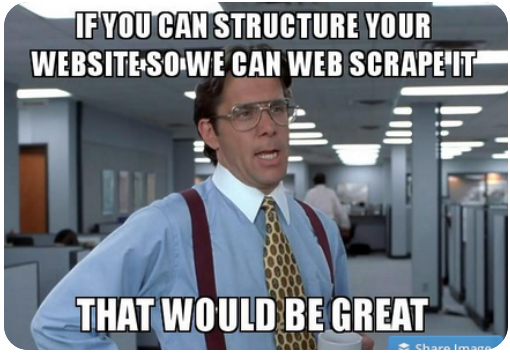

Fonte da figura: algum lugar da *Web* que não lembro mais.

# Preliminares

## Fontes de dados na Web

1. Dados já coletados e disponibilizados
 * https://archive.ics.uci.edu/datasets
 * https://zenodo.org/
 * https://www.kaggle.com/datasets
 * https://snap.stanford.edu/data/
 * ...
2. Coleta manual
3. *Web scraping* + *Web crawling*
4. Uso de APIs

## Considerações éticas e legais

Não é porque você **sabe** fazer que você **deve** fazer

Aspectos legais e éticos sempre devem ser considerados antes de iniciar uma coleta de dados na Web

O objetivo dessa aula é **apenas** apresentar técnicas e tecnologias para coleta de dados.

**Boa prática:** sempre consulte o ``robots.txt`` de um *site* antes de iniciar uma coleta,
  * exemplo: https://facebook.com/robots.txt.
  * Leia mais sobre ``robots.txt`` em https://en.wikipedia.org/wiki/Robots_exclusion_standard

## Qual biblioteca utilizar?

A estrutura das páginas da *Web* não segue um padrão. "A Web não é um mundo civilizado". Assim, vamos precisar de uma série de ferramentas (e possivelmente *gambiarras*) toda vez que iniciarmos uma coleta.

No princípio, a *Web* era HTTP + HTML...
* ``urllib`` (https://docs.python.org/3/library/urllib.html)
* ``re`` (https://docs.python.org/3/library/re.html, https://regexr.com/, https://regex101.com/)
* ``Beautiful Soup`` (https://www.crummy.com/software/BeautifulSoup/bs4/doc/)

Depois, inventaram ``javascript``...
* ``Selenium`` (https://selenium-python.readthedocs.io/)



# Coletando um conjunto de páginas simples

Precisaremos executar os seguintes passos:
1. Fazer uma requisição HTTP para obter o contúdo (código fonte) da página de interesse;
2. Identificar a estrutura da página que contém o conteúdo de interesse
3. Usar expressões regulares e/ou ``beautiful soup`` para extrair o conteúdo
4. Torcer (rezar?) para o proprietário da página:
  * não mudar a estrutura durante sua coleta
  * não te bloquear por excesso de requisições

## Obtendo a página com ``urllib``

In [ ]:
import urllib.error
import urllib.request
import socket

In [ ]:
def get_page(url):
    try:
        req = urllib.request.Request(url, headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/35.0.1916.47 Safari/537.36'})
        with urllib.request.urlopen(req, timeout = 5) as f:
            return f.read()
    except socket.timeout as e1:
        print('\tTime out')
    except urllib.error.URLError as e2:
        print('\tURL error')
    except urllib.error.HTTPError as e3:
        print('\tHTTP error')
    return None

In [ ]:
content = get_page('http://www.google.com')

In [ ]:
type(content)

bytes

In [ ]:
decoded = content.decode('utf-8')

In [ ]:
type(decoded)

str

In [ ]:
print(decoded)

<!doctype html><html itemscope="" itemtype="http://schema.org/WebPage" lang="en"><head><meta content="Search the world's information, including webpages, images, videos and more. Google has many special features to help you find exactly what you're looking for." name="description"><meta content="noodp, " name="robots"><meta content="text/html; charset=UTF-8" http-equiv="Content-Type"><meta content="/images/branding/googleg/1x/googleg_standard_color_128dp.png" itemprop="image"><title>Google</title><script nonce="vbL_MU8IGxSCFpIJC32WxA">(function(){var _g={kEI:'PWHtaIb-BeSuwbkP6YmqqAI',kEXPI:'0,202854,2,35,615991,3421163,48791,46127,344796,94243,5821,147256,42724,5230280,32780335,4043709,25228681,117306,6682,14280,14115,57125,5382,2662,3432,27198,9138,4600,328,6225,64165,6747,8302,8210,3286,4134,30380,28333,10904,42051,1258,352,10700,8180,5870,7707,7,5773,15029,12583,4719,11805,6251,28,7,1,1293,2126,2863,1,206,5764,4650,2360,9747,5683,1,3604,17764,7,1,2723,6,16551,675,1225,2,1,1595,11806

## Extraindo conteúdo de interesse do HTML

### Mundo ideal

Exemplo extraído do *Quick Start* da biblioteca ``beautiful soup``

In [ ]:
html_doc = """<html><head><title>The Dormouse's story</title></head>
<body>
<p class="title"><b>The Dormouse's story</b></p>

<p class="story">Once upon a time there were three little sisters; and their names were
<a href="http://example.com/elsie" class="sister" id="link1">Elsie</a>,
<a href="http://example.com/lacie" class="sister" id="link2">Lacie</a> and
<a href="http://example.com/tillie" class="sister" id="link3">Tillie</a>;
and they lived at the bottom of a well.</p>

<p class="story">...</p>
"""

In [ ]:
from bs4 import BeautifulSoup

In [ ]:
soup = BeautifulSoup(html_doc, 'html.parser')

In [ ]:
print(soup.prettify())

<html>
 <head>
  <title>
   The Dormouse's story
  </title>
 </head>
 <body>
  <p class="title">
   <b>
    The Dormouse's story
   </b>
  </p>
  <p class="story">
   Once upon a time there were three little sisters; and their names were
   <a class="sister" href="http://example.com/elsie" id="link1">
    Elsie
   </a>
   ,
   <a class="sister" href="http://example.com/lacie" id="link2">
    Lacie
   </a>
   and
   <a class="sister" href="http://example.com/tillie" id="link3">
    Tillie
   </a>
   ;
and they lived at the bottom of a well.
  </p>
  <p class="story">
   ...
  </p>
 </body>
</html>



In [ ]:
soup.title

<title>The Dormouse's story</title>

In [ ]:
soup.title.name

'title'

In [ ]:
soup.title.string

"The Dormouse's story"

In [ ]:
soup.title.parent.name

'head'

In [ ]:
soup.p

<p class="title"><b>The Dormouse's story</b></p>

In [ ]:
soup.p['class']

['title']

In [ ]:
soup.a

<a class="sister" href="http://example.com/elsie" id="link1">Elsie</a>

In [ ]:
soup.find_all('a')

[<a class="sister" href="http://example.com/elsie" id="link1">Elsie</a>,
 <a class="sister" href="http://example.com/lacie" id="link2">Lacie</a>,
 <a class="sister" href="http://example.com/tillie" id="link3">Tillie</a>]

In [ ]:
soup.find(id="link3")

<a class="sister" href="http://example.com/tillie" id="link3">Tillie</a>

In [ ]:
for link in soup.find_all('a'):
    print(link.get('href'))

http://example.com/elsie
http://example.com/lacie
http://example.com/tillie


In [ ]:
for p in soup.find_all('p'):
    print(p.get_text())

The Dormouse's story
Once upon a time there were three little sisters; and their names were
Elsie,
Lacie and
Tillie;
and they lived at the bottom of a well.
...


In [ ]:
print(soup.get_text())

The Dormouse's story

The Dormouse's story
Once upon a time there were three little sisters; and their names were
Elsie,
Lacie and
Tillie;
and they lived at the bottom of a well.
...



### Mundo real

Vamos considerar um exemplo do mundo real para ver como Python pode ser útil.

Página de interesse: https://www.sofis.com.br/noticias/7-erros-de-governanca-de-dados-para-evitar/

Suponha que queiramos extrair as seguintes informações:
* Título
* Subtítulo
* Autor
* Data/hora

O interessante dessa página é que o HTML contém todas essas informações. Logo, ``re`` e ``beautiful soup`` são suficientes para a nossa tarefa.

Primeiro, vamos obter o código fonte da página.

In [ ]:
# content = get_page('https://cio.com.br/seguranca/7-erros-de-governanca-de-dados-para-evitar/')
content = get_page('https://www.sofis.com.br/noticias/7-erros-de-governanca-de-dados-para-evitar/')
content = content.decode('utf-8')

Vamos criar o objeto da classe ``BeautifuSoulp``

In [ ]:
soup =  BeautifulSoup(content, features="html5lib")

In [ ]:
print(soup.prettify())

<html lang="pt-BR">
 <head>
 </head>
 <body>
  ﻿
  <!--[if IE 7]>
<html class="ie ie7" lang="pt-BR">
<![endif]-->
  <!--[if IE 8]>
<html class="ie ie8" lang="pt-BR">
<![endif]-->
  <!--[if !(IE 7) & !(IE 8)]><!-->
  <!--<![endif]-->
  <meta charset="utf-8"/>
  <meta content="IE=Edge" http-equiv="X-UA-Compatible"/>
  <meta content="Sofis Tecnologia - Empresa com mais de 25 anos de experiência em Tecnologia da Informação. Especializada em projetos na área de saúde." name="description"/>
  <meta content="Sofis Tecnologia" name="author"/>
  <meta content="Informática, Banco de sangue, Sistemas de hemoterapia, Isbt 128, Hemoterapia, Segurança transfusional, Celulas tronco, Cordao umbilical, Resultados via web, Gestão hospitalar, Hemote, Hemote Plus, Lab+, Salute, Hemote ID, Cell Vida, Monetario, Monetários, GCA - Gestão de Compras e Abastecimento, Humano, Património, FRESENIUS, CEI, PALM, VJR, MATRIX" name="Keywords"/>
  <title>
   7 erros de governança de dados para evitar - SOFIS TECNOLOG

Todos os metadados estão em uma parte bem definida e estruturada do HTML

#### *Source code* em 2021/2

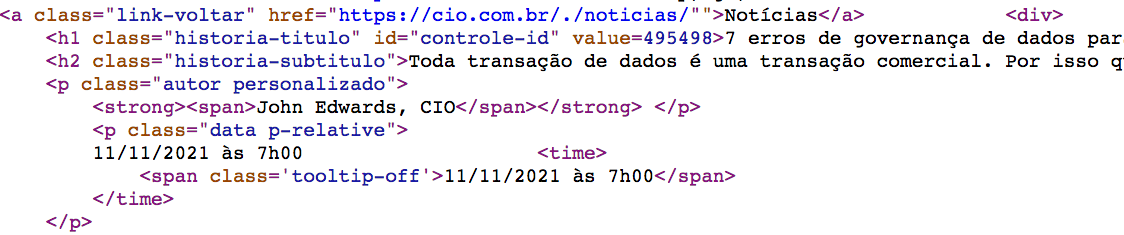

#### *Source code* em 2022/2

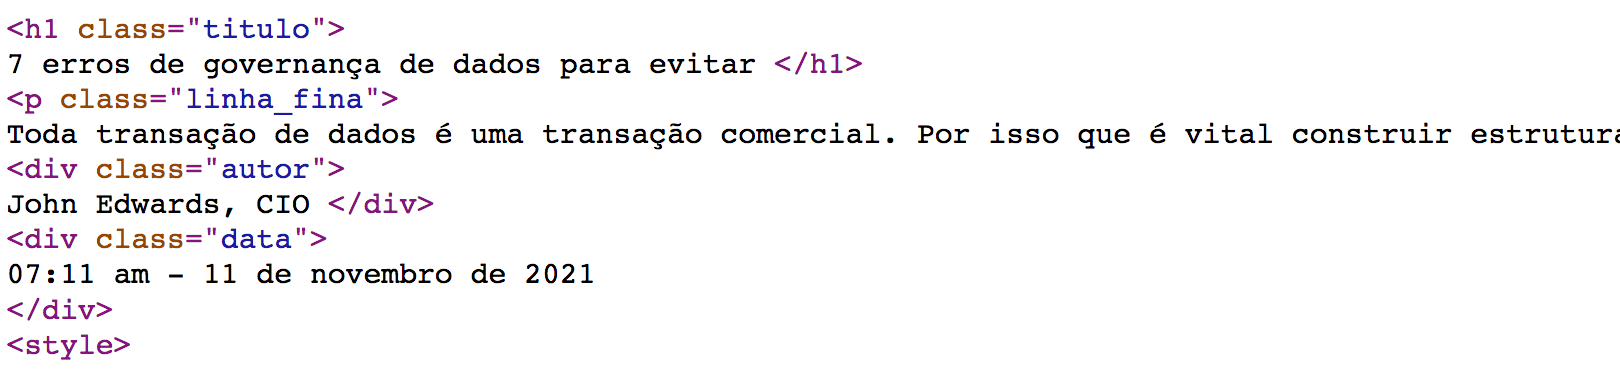

#### *Source code* em 2023/2

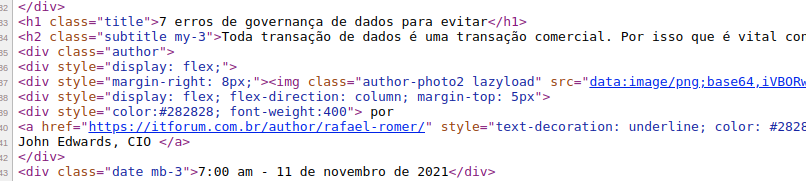

#### *Source code* em 2024/2 e 2025/2

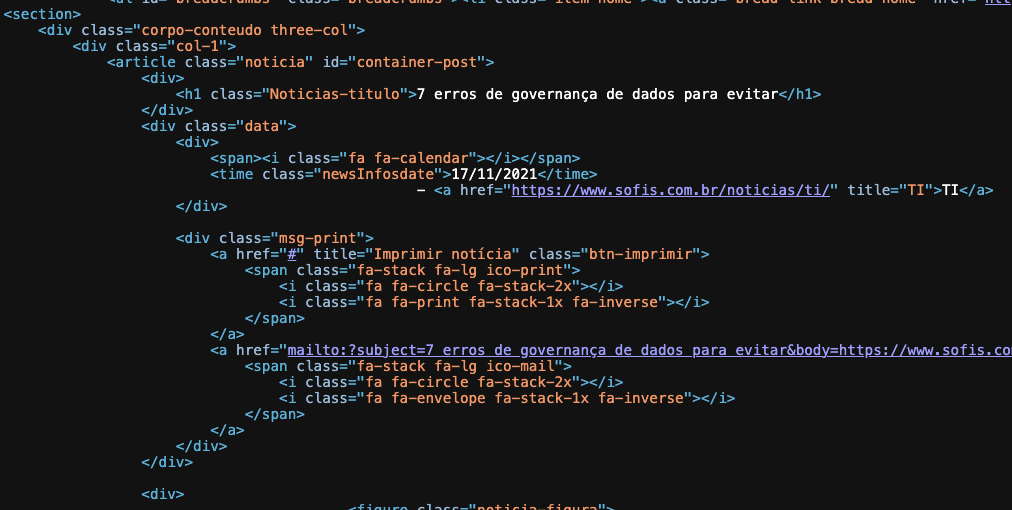

#### Título

In [ ]:
soup.find('h1', {'class': 'Noticias-titulo'}).get_text().strip()

'7 erros de governança de dados para evitar'

#### Subtítulo

In [ ]:
# não tem mais =(
# soup.find('h2', {'class': 'subtitle my-3'}).get_text().strip()

#### Autor

In [ ]:
# não tem mais =(
#soup.find('div', {'class': 'author'}).get_text().strip()

In [ ]:
# soup.find('div', {'class': 'author'}).get_text().strip().split(',')[0].split('\n')[-1]

#### Data/hora

In [ ]:
soup.find('time', {'class': 'newsInfosdate'}).get_text().strip()

'17/11/2021'

#### Texto

##### Tentativa 1

In [ ]:
print(soup.get_text())

﻿






    
    
    
    
    

    7 erros de governança de dados para evitar - SOFIS TECNOLOGIA

    
    
    
    
    
    

    

    
    
    
    7 erros de governança de dados para evitar - SOFIS TECNOLOGIA
    
    

    
    
    
    
    
    
    
    

        

    
    
    
    
    
    
    
    
    

    
	
	
	
		var _gaq = _gaq || [];
		_gaq.push(['_setAccount', 'UA-33522787-1']);
		_gaq.push(['_trackPageview']);

		(function() {
		var ga = document.createElement('script'); ga.type = 'text/javascript'; ga.async = true;
		ga.src = ('https:' == document.location.protocol ? 'https://ssl' : 'http://www') + '.google-analytics.com/ga.js';
		var s = document.getElementsByTagName('script')[0]; s.parentNode.insertBefore(ga, s);
		})();
	

    

	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	{"@context":"https://schema.org","@graph":[{"@type":"Organization","@id":"https://www.sofis.com.br/#organization","name":"Sofis Tecnologia","url":"https://www.sofis.com.br/","sameAs":["http

##### Tentativa 2

O Texto está dentro de uma ``div`` com classe ``bloco-texto``.
Mas veja que há vários blocos de ``javascript`` dentro do texto também.

###### *Source code* 2021/2

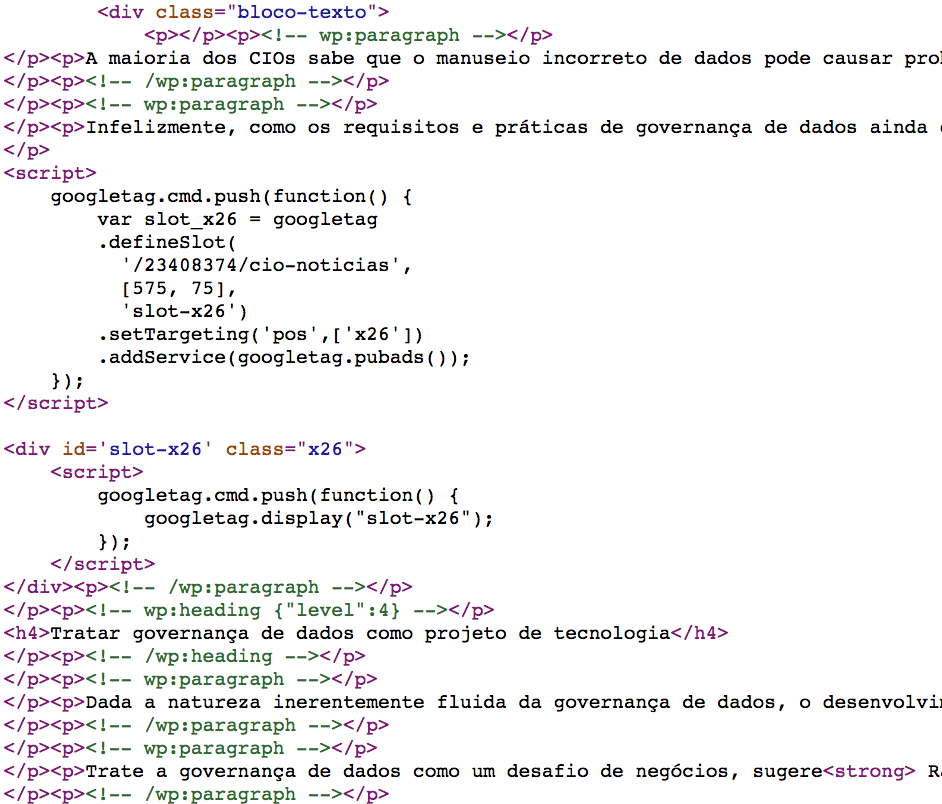

Tentativa 3 (Necessária em 2021/2 -- não funciona na versão atual da página)

Vamos usar expressões regulares para limpar o texto.

PS: isso também poderia ser feito com código nativo ``beautiful soup`` (e.g., método ``decompose()``). No entanto, eu quis ilustrar o uso de expressões regulares aqui também.

In [ ]:
# não execute, apenas de exemplo do código antigo
#import re

O que significa a expressão regular abaixo?

In [ ]:
# não execute, apenas de exemplo do código antigo
#my_re = re.compile('googletag\.cmd.+?\}\);', re.MULTILINE | re.DOTALL)

Substituindo todos os *matches* da expressão acima com uma *string* vazia.

In [ ]:
# não execute, apenas de exemplo do código antigo
#text_after = re.sub(my_re, '', text)

In [ ]:
# não execute, apenas de exemplo do código antigo
#print(text_after)

Por fim, vamos só deixar o texto mais "agradável" aos olhos.

In [ ]:
# não execute, apenas de exemplo do código antigo
#import textwrap

In [ ]:
# não execute, apenas de exemplo do código antigo
#print(textwrap.fill(textwrap.dedent(text_after).strip(), width = 80))

###### *Source code* 2022/2

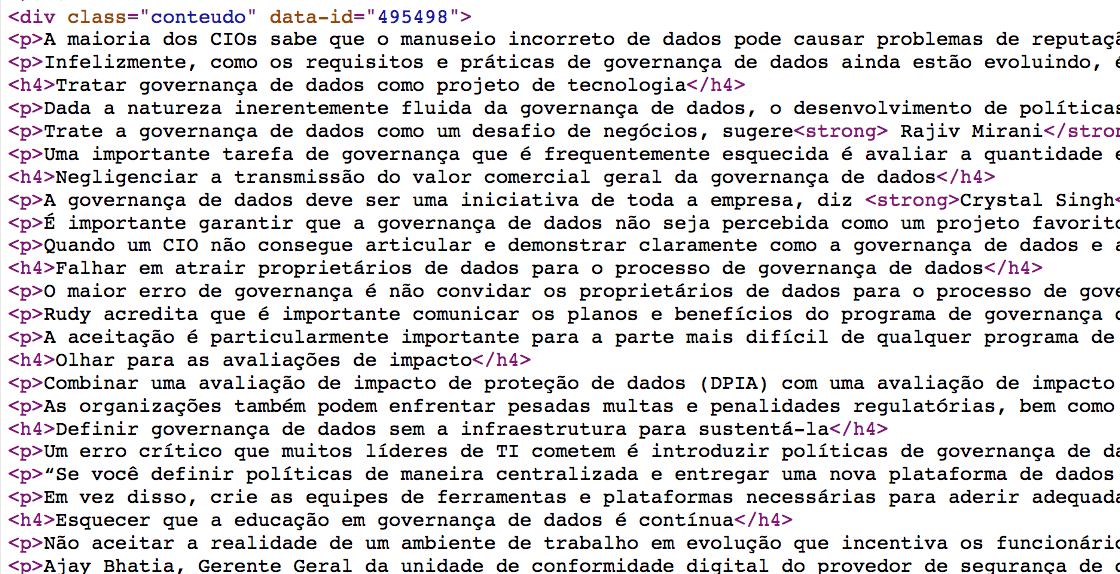

#### *Source code* em 2023/2

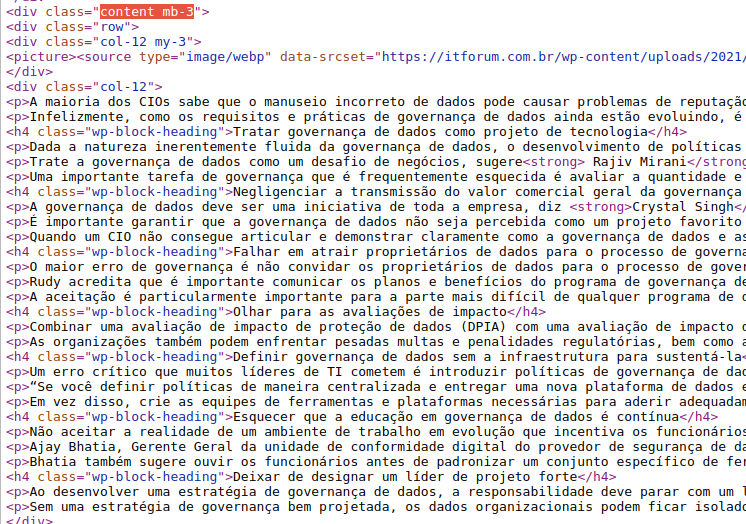

O código abaixo não funcionava nos anos passados. Aparentemente, a estrutura da página foi melhorada a cada anao.

In [ ]:
#text = soup.find('div', {'class': 'content mb-3'}).get_text()

In [ ]:
#print(text)

#### *Source code* em 2024/2 e 2025/2

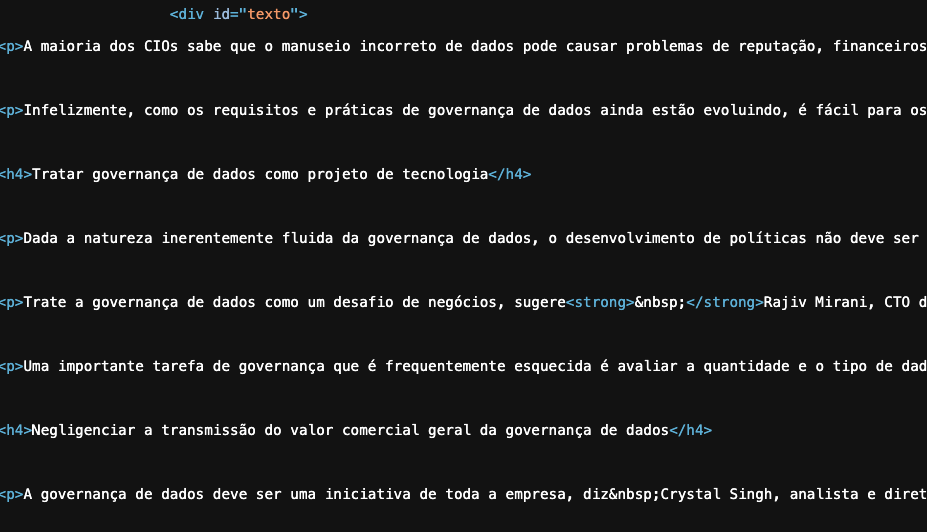

In [ ]:
text = soup.find('div', {'id': 'texto'}).get_text()

In [ ]:
print(text)


                        
A maioria dos CIOs sabe que o manuseio incorreto de dados pode causar problemas de reputação, financeiros, jurídicos e dos mais diversos tipos. É por isso que ter uma política de governança de dados forte, que garanta segurança e conformidade, mas também seja acessível e gerenciável, é uma prioridade para qualquer organização que está comprometida com a integridade e preservação dos dados.



Infelizmente, como os requisitos e práticas de governança de dados ainda estão evoluindo, é fácil para os líderes de TI cair em armadilhas que, com o tempo, podem minar até mesmo os melhores esforços de planejamento pretendidos. Para evitar que sua organização caia em uma armadilha que pode tornar sua política de governança de dados ineficaz ou mesmo perigosa, fique atento aos sete erros comuns a seguir que devem ser evitados a todo custo.



Tratar governança de dados como projeto de tecnologia



Dada a natureza inerentemente fluida da governança de dados, o desenvolvim

#### Colocando toda a lógica acima em uma única função

In [ ]:
# Versão 2022/2

#import textwrap
#def get_cio_page_data(url):
#  content = get_page(url)
#  content.decode('utf-8')
#  soup =  BeautifulSoup(content, features="html5lib")
#
#  title = soup.find('h1', {'class': 'titulo'}).get_text().strip()
#  subtitle = soup.find('p', {'class': 'linha_fina'}).get_text().strip()
#  author = soup.find('div', {'class': 'autor'}).get_text().strip()
#  date = soup.find('div', {'class': 'data'}).get_text().strip()
#
#  text = soup.find('div', {'class': 'conteudo'}).get_text()
#  text = textwrap.fill(textwrap.dedent(text).strip(), width = 80)

#  return {'title': title, 'subtitle': subtitle, 'author': author, 'date': date, 'text': text}

In [ ]:
# Versão 2023/2

#import textwrap
#def get_cio_page_data(url):
#  content = get_page(url)
#  content.decode('utf-8')
#  soup =  BeautifulSoup(content, features="html5lib")

#  title = soup.find('h1', {'class': 'title'}).get_text().strip()
#  subtitle = soup.find('h2', {'class': 'subtitle my-3'}).get_text().strip()
#  author = soup.find('div', {'class': 'author'}).get_text().strip().split(',')[0].strip().split('\n')[2]
#  date = soup.find('div', {'class': 'date mb-3'}).get_text().strip()

#  text = soup.find('div', {'class': 'content mb-3'}).get_text()
#  text = textwrap.fill(textwrap.dedent(text).strip(), width = 80)

#  return {'title': title, 'subtitle': subtitle, 'author': author, 'date': date, 'text': text}

In [ ]:
# Versão 2024/2 e 2025/2

import textwrap
def get_cio_page_data(url):
  content = get_page(url)
  content.decode('utf-8')
  soup =  BeautifulSoup(content, features="html5lib")

  title = soup.find('h1', {'class': 'Noticias-titulo'}).get_text().strip()
  #subtitle = soup.find('h2', {'class': 'subtitle my-3'}).get_text().strip()
  #author = soup.find('div', {'class': 'author'}).get_text().strip().split(',')[0].strip().split('\n')[2]
  date = soup.find('time', {'class': 'newsInfosdate'}).get_text().strip()

  text = soup.find('div', {'id': 'texto'}).get_text()
  text = textwrap.fill(textwrap.dedent(text).strip(), width = 80)

  return {'title': title, 'date': date, 'text': text}

In [ ]:
get_cio_page_data('https://www.sofis.com.br/noticias/7-erros-de-governanca-de-dados-para-evitar/')

{'title': '7 erros de governança de dados para evitar',
 'date': '17/11/2021',
 'text': 'A maioria dos CIOs sabe que o manuseio incorreto de dados pode causar problemas\nde reputação, financeiros, jurídicos e dos mais diversos tipos. É por isso que\nter uma política de governança de dados forte, que garanta segurança e\nconformidade, mas também seja acessível e gerenciável, é uma prioridade para\nqualquer organização que está comprometida com a integridade e preservação dos\ndados.    Infelizmente, como os requisitos e práticas de governança de dados\nainda estão evoluindo, é fácil para os líderes de TI cair em armadilhas que, com\no tempo, podem minar até mesmo os melhores esforços de planejamento pretendidos.\nPara evitar que sua organização caia em uma armadilha que pode tornar sua\npolítica de governança de dados ineficaz ou mesmo perigosa, fique atento aos\nsete erros comuns a seguir que devem ser evitados a todo custo.    Tratar\ngovernança de dados como projeto de tecnologia    

In [ ]:
get_cio_page_data('https://www.sofis.com.br/noticias/o-impacto-da-tecnologia-na-saude/')

{'title': 'Os avanços tecnológicos e o impacto da tecnologia na saúde',
 'date': '27/07/2017',
 'text': 'A tecnologia impacta a sociedade em todos os aspectos, porém em nenhum outro\nsetor esse impacto é mais aparente quanto na saúde. Os avanços tecnológicos\ncompreendem a adoção de prontuários eletrônicos, avanços em engenharia e\ntecnologia biomédica, entre outros. A área da saúde vivencia uma mudança na\nforma como os cuidados de saúde estão sendo entregues. Porém que impactos essas\nmudanças trarão na prestação geral de cuidados? De acordo com o infográfico, a\ntecnologia afetou significativamente o campo da saúde em frentes como\ncomunicação, tratamento, pesquisa e coleta de informações. Ao longo do tempo,\nesses avanços continuarão a avançar e seus reflexos poderão ser compreendidos na\nqualidade geral dos cuidados de saúde para pacientes e médicos em todo o mundo.\n60 milhões de pessoas usam redes sociais para atividades relacionadas à saúde;\n9.000 aplicativos médicos e médicos

In [ ]:
get_cio_page_data('https://www.sofis.com.br/noticias/ti/gastos-com-ti-devem-cresc/')

{'title': 'Gastos mundiais com TI devem crescer 4,3% em 2023, diz Gartner',
 'date': '27/07/2023',
 'text': 'Os gastos mundiais com TI devem crescer 4,3% em 2023, segundo estimativa do\nGartner. A expectativa é de que esse crescimento represente um total de US$ 4,7\ntrilhões no ano. Esse aumento, na análise da consultoria, seria decorrente da\ntransferência dos gastos com talentos de TI para tecnologias que permitem\nautomação. A ideia dos CIOs, de acordo com o Gartner, é impulsionar o\ncrescimento em escala com menos funcionários.    “As transformações dos negócios\ndigitais estão começando a mudar”, diz John-David Lovelock, vice-presidente e\nanalista do Gartner. “Os projetos de TI estão trocando de foco, de entregas\nvoltadas para o exterior, como receita e experiência dos clientes, para esforços\nmais voltados para em aspectos internos, focados na otimização.”    O segmento\nde software deve ter um crescimento de dois dígitos em 2023, à medida que as\norganizações aumentarem a util

#### Minha reação toda vez que tenho que codificar algo assim

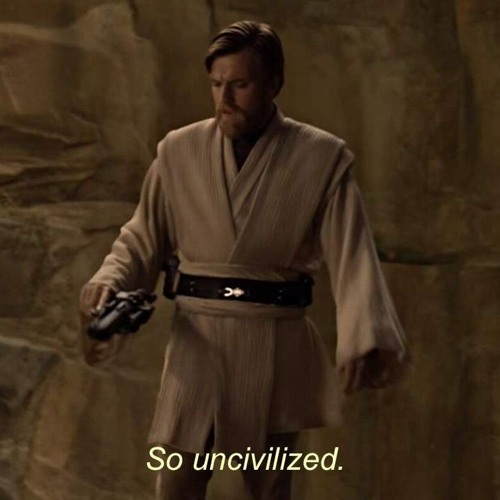

# Simulando um usuário para coletar páginas complexas

Exemplo usando ``Selenium``


# What is next?

É importante que entendam as dificuldades de uma coleta de dados.
Levem isso em consideração para escolherem o tema do projeto final da disciplina (especificação sai em breve)